In [1]:
import pandas as pd
from pathlib import Path
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
import numpy as np
import re
import ast
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import normalize
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
import umap

In [2]:
tag_embeddings = pd.read_csv("input/tag_embeddings.csv")
tag_embeddings.head(5)

,location_id,name,description,web_url,latitude,longitude,website,write_review,rating,rating_image_url,...,rating_5_review_count,tags,trip_types_solo,trip_types_couples,trip_types_business,trip_types_family,trip_types_friends,cleaned_tags,tag_embeddings,cluster
0,456633.0,House of Opium,Located in the heart of the infamous Golden Tr...,https://www.tripadvisor.com/Attraction_Review-...,20.351446,100.081660,https://www.tourismthailand.org/Attraction/Hou...,https://www.tripadvisor.com/UserReview-g317131...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,413.0,"History Museums, Specialty Museums",105.0,440.0,9.0,148.0,184.0,history museum specialty museum,[ 2.5900002e-03 -6.5010088e-04 -3.8178414e-03 ...,0
1,23933132.0,Opium Bar,NaN,https://www.tripadvisor.com/Attraction_Review-...,13.739190,100.508500,http://www.opiumbarbangkok.com/,https://www.tripadvisor.com/UserReview-g293916...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,4.0,Bars & Clubs,0.0,3.0,0.0,0.0,2.0,bar club,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,21
2,7099963.0,Wat Phra That Doi Saket,NaN,https://www.tripadvisor.com/Attraction_Review-...,18.872380,99.139930,NaN,https://www.tripadvisor.com/UserReview-g196165...,4.5,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,44.0,Sacred & Religious Sites,9.0,26.0,0.0,14.0,21.0,sacred religious,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,15
3,1390125.0,Mae Ping River Cruise,Leave from the jetty at Wat Chai Mongkol and t...,https://www.tripadvisor.com/Attraction_Review-...,18.780819,99.005210,http://www.maepingrivercruise.com/,https://www.tripadvisor.com/UserReview-g293917...,3.5,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,102.0,Boat Tours,31.0,186.0,2.0,43.0,57.0,boat tour,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,10
4,547675.0,Pai River,NaN,https://www.tripadvisor.com/Attraction_Review-...,19.359318,98.445305,NaN,https://www.tripadvisor.com/UserReview-g303916...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,52.0,Bodies of Water,30.0,56.0,1.0,15.0,46.0,body water,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,28


In [107]:
def optimize_n_clusters(data, max_clusters=30):

    best_n_clusters = None
    best_silhouette = -1
    best_dbi = float('inf')
    results = []

    for n_clusters in range(2, max_clusters + 1):
        print(f"🔄 Testing {n_clusters} clusters...")

        clusterer = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
        labels = clusterer.fit_predict(data)

        # Ensure at least 2 clusters exist
        if len(set(labels)) > 1:
            silhouette_avg = silhouette_score(data, labels)
            dbi_score = davies_bouldin_score(data, labels)
            results.append((n_clusters, silhouette_avg, dbi_score))

            # Select best model based on highest silhouette score and lowest DBI
            if silhouette_avg > best_silhouette or (silhouette_avg == best_silhouette and dbi_score < best_dbi):
                best_silhouette = silhouette_avg
                best_dbi = dbi_score
                best_n_clusters = n_clusters

    # Convert results to DataFrame
    results_df = pd.DataFrame(results, columns=["n_clusters", "silhouette_score", "dbi_score"])

    # Plot metrics
    plt.figure(figsize=(10, 5))
    plt.plot(results_df["n_clusters"], results_df["silhouette_score"], marker='o', label="Silhouette Score")
    plt.plot(results_df["n_clusters"], results_df["dbi_score"], marker='s', label="Davies-Bouldin Index")
    plt.xlabel("Number of Clusters")
    plt.ylabel("Score")
    plt.title("Cluster Quality Metrics")
    plt.legend()
    plt.grid()
    plt.show()

    print(f"✅ Best n_clusters: {best_n_clusters} (Silhouette Score: {best_silhouette:.4f}, DBI: {best_dbi:.4f})")

    return best_n_clusters, results_df


/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


🔄 Testing 2 clusters...
🔄 Testing 3 clusters...
🔄 Testing 4 clusters...
🔄 Testing 5 clusters...
🔄 Testing 6 clusters...
🔄 Testing 7 clusters...
🔄 Testing 8 clusters...
🔄 Testing 9 clusters...
🔄 Testing 10 clusters...
🔄 Testing 11 clusters...
🔄 Testing 12 clusters...
🔄 Testing 13 clusters...
🔄 Testing 14 clusters...
🔄 Testing 15 clusters...
🔄 Testing 16 clusters...
🔄 Testing 17 clusters...
🔄 Testing 18 clusters...
🔄 Testing 19 clusters...
🔄 Testing 20 clusters...
🔄 Testing 21 clusters...
🔄 Testing 22 clusters...
🔄 Testing 23 clusters...
🔄 Testing 24 clusters...
🔄 Testing 25 clusters...
🔄 Testing 26 clusters...
🔄 Testing 27 clusters...
🔄 Testing 28 clusters...
🔄 Testing 29 clusters...
🔄 Testing 30 clusters...


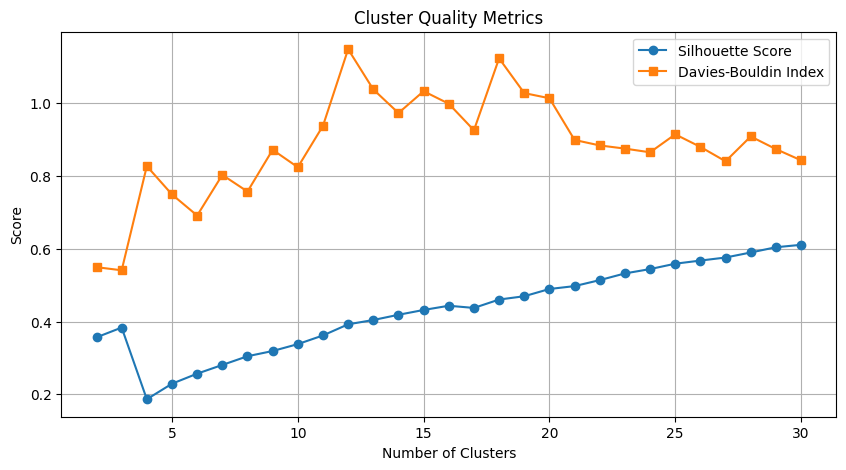

✅ Best n_clusters: 30 (Silhouette Score: 0.6107, DBI: 0.8428)


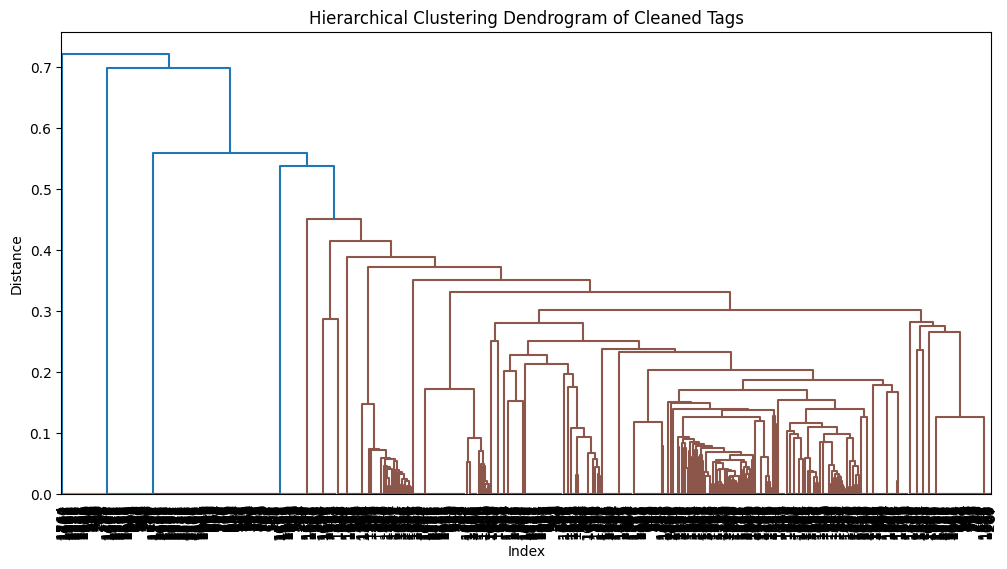

In [108]:
tag_embeddings['cleaned_tags']# 🔹 Load your dataset
tags = tag_embeddings["cleaned_tags"].dropna().astype(str)  # Remove NaN values

# 🔹 Tokenize the cleaned_tags column
tokenized_tags = [tag.split() for tag in tags]

# 🔹 Train a Word2Vec model (or load a pre-trained model)
w2v_model = Word2Vec(sentences=tokenized_tags, vector_size=100, window=5, min_count=1, sg=0, workers=4)  # CBOW model

# 🔹 Compute TF-IDF scores
vectorizer = TfidfVectorizer(tokenizer=lambda x: x.split(), lowercase=False)
tfidf_matrix = vectorizer.fit_transform(tags)  # TF-IDF for entire dataset
tfidf_vocab = vectorizer.vocabulary_  # Get vocab dictionary

# 🔹 Function to generate TF-IDF weighted Word2Vec embeddings
def get_weighted_sentence_embedding(sentence):
    words = sentence.split()
    word_vectors = []
    for word in words:
        if word in w2v_model.wv and word in tfidf_vocab:
            tfidf_weight = tfidf_matrix[tags.tolist().index(sentence), tfidf_vocab[word]]  # Get TF-IDF weight
            word_vectors.append(tfidf_weight * w2v_model.wv[word])  # Weighted word vector
    
    if word_vectors:
        return np.mean(word_vectors, axis=0)  # Average word vectors
    else:
        return np.zeros(w2v_model.vector_size)  # Default zero vector if no valid words

# 🔹 Generate embeddings for all cleaned_tags
tag_embeddings_matrix = np.array([get_weighted_sentence_embedding(tag) for tag in tags])


# 🔹 Run optimization
best_n_clusters, results_df = optimize_n_clusters(tag_embeddings_matrix, max_clusters=30)

# 🔹 Apply Hierarchical Clustering
linkage_matrix = linkage(tag_embeddings_matrix, method="ward")  # Ward linkage for Euclidean distances

# # 🔹 Plot Dendrogram for visualization
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, labels=tags.index, leaf_rotation=90, leaf_font_size=10)
plt.title("Hierarchical Clustering Dendrogram of Cleaned Tags")
plt.xlabel("Index")
plt.ylabel("Distance")
plt.show()


In [109]:

clusterer = AgglomerativeClustering(n_clusters=best_n_clusters, linkage="ward")
clusters = clusterer.fit_predict(tag_embeddings_matrix)

# 🔹 FIX: Assign clusters back to the original DataFrame
tag_embeddings["cluster"] = -1  # Initialize all rows to -1
tag_embeddings.loc[tags.index, "cluster"] = clusters  # Assign clusters only to non-null rows


In [110]:
tag_embeddings[['cluster', 'cleaned_tags']]

,cluster,cleaned_tags
0,0,history museum specialty museum
1,21,bar club
2,15,sacred religious
3,10,boat tour
4,28,body water
...,...,...
1761,7,beach
1762,20,bridge
1763,2,sacred religious architectural building
1764,7,beach


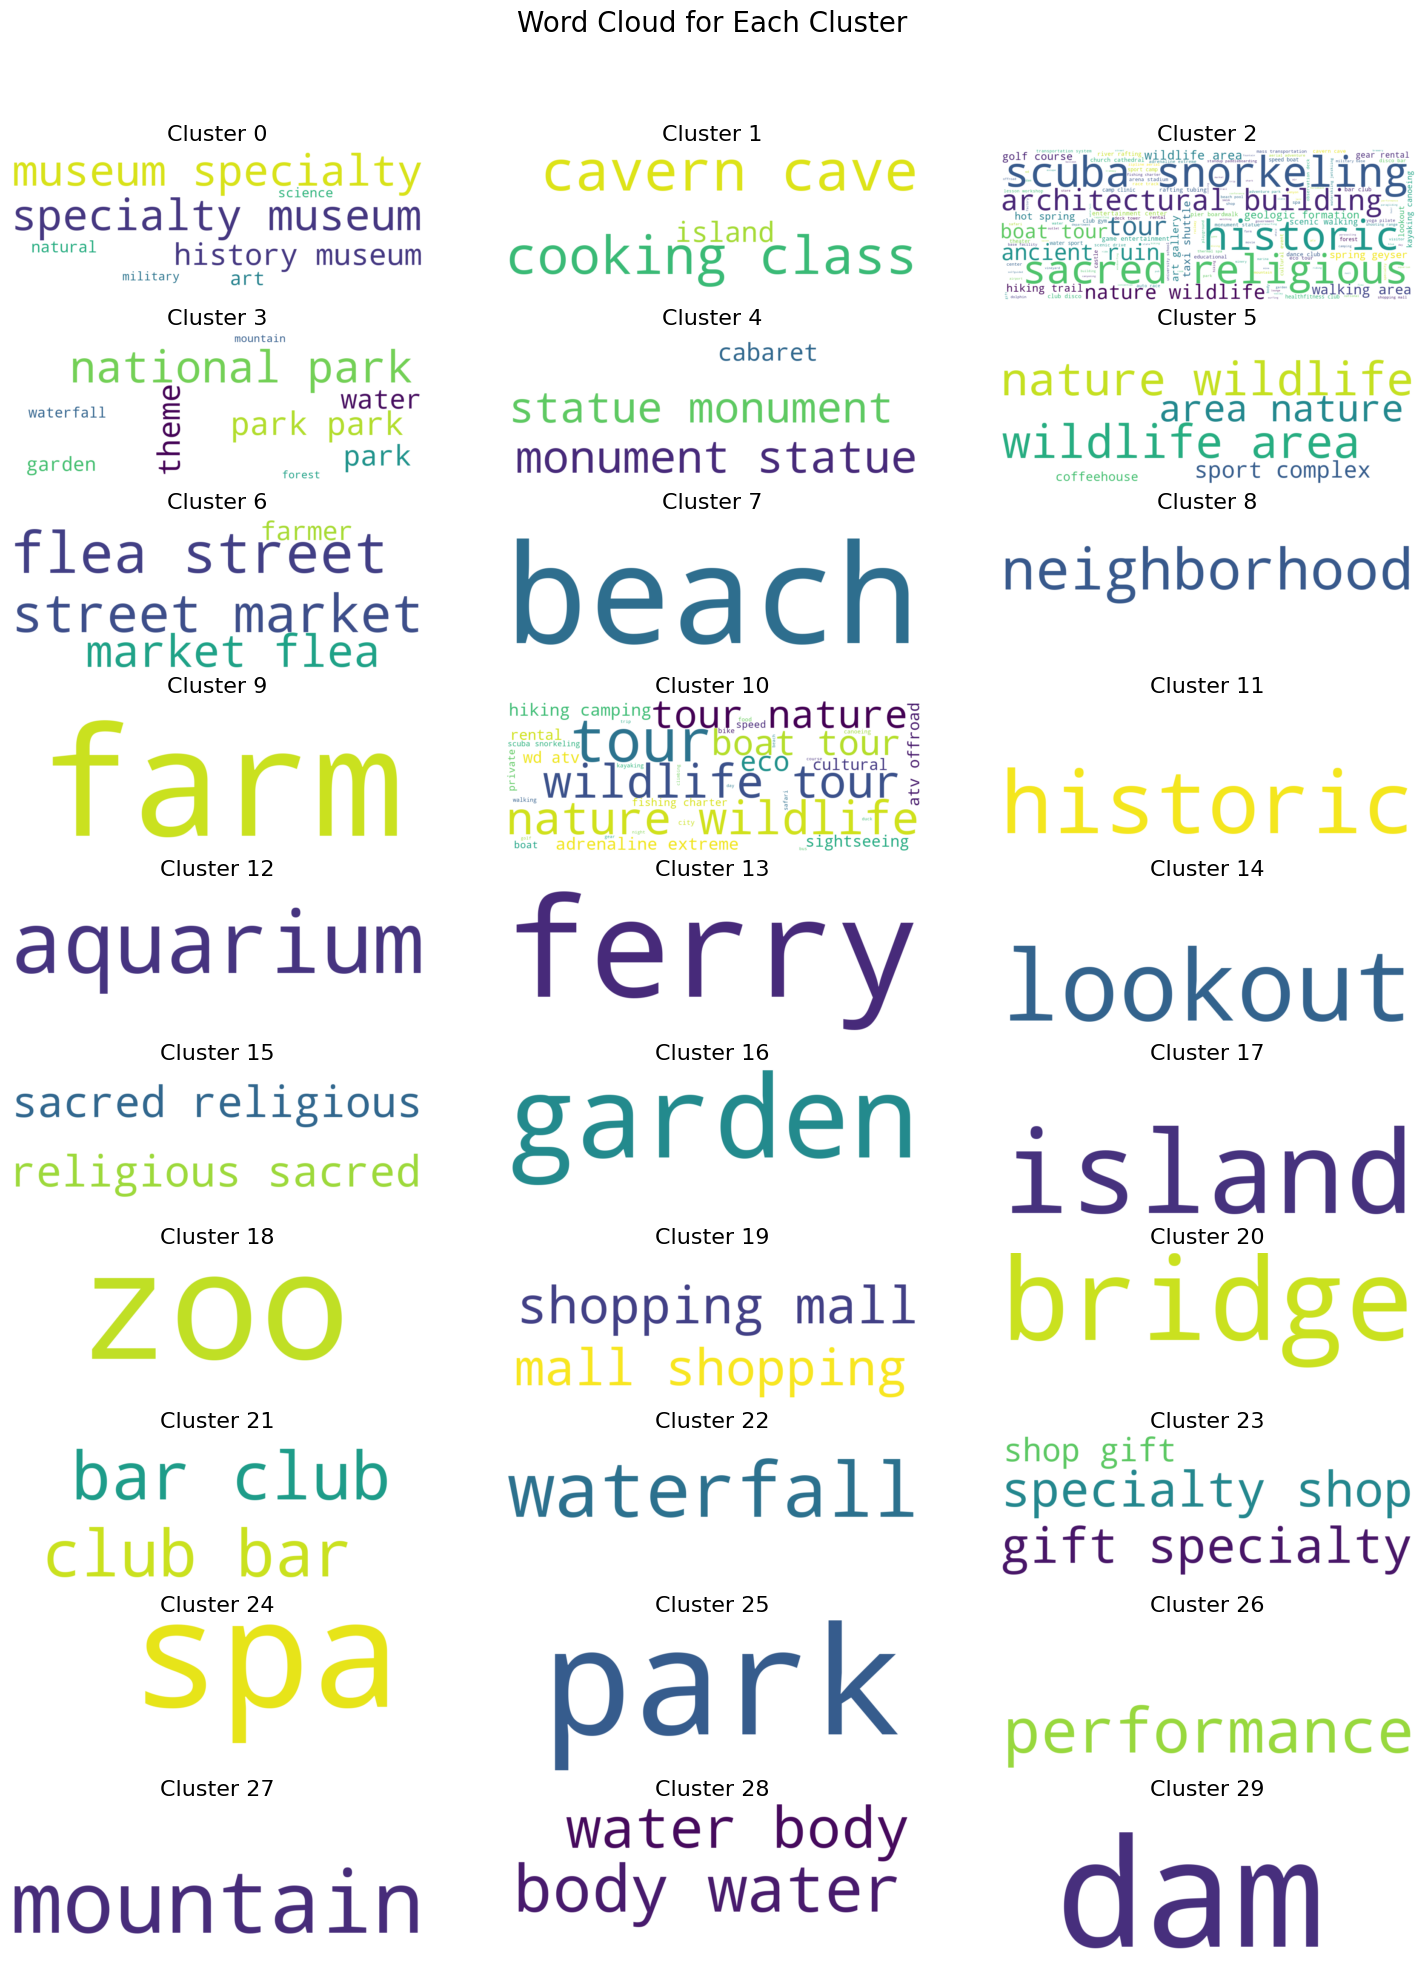

In [119]:
clearned_tags = tag_embeddings
clearned_tags['cleaned_tags'] = clearned_tags['cleaned_tags'].fillna('').astype(str).str.strip()

group_tags_df = clearned_tags.groupby('cluster')['cleaned_tags'].apply(lambda x: ' '.join(x)).to_dict()


# Remove clusters with no words
cleaned_data = {k: v for k, v in group_tags_df.items() if v.strip()}

if not cleaned_data:
    print("No valid word clouds to generate.")
else:
    # Plot Word Clouds
    num_clusters = len(cleaned_data)
    columns = 3
    rows = (num_clusters + columns - 1) // columns

    fig, axes = plt.subplots(rows, columns, figsize=(15, 2 * rows))
    fig.suptitle("Word Cloud for Each Cluster", fontsize=20)

    axes = axes.flatten()

    for idx, (cluster_id, words) in enumerate(cleaned_data.items()):
        if words.strip():  # Ensure there are actual words
            wordcloud = WordCloud(width=1100, height=400, background_color='white').generate(words)
            axes[idx].imshow(wordcloud, interpolation='bilinear')
            axes[idx].set_title(f"Cluster {cluster_id}", fontsize=16)
            axes[idx].axis('off')
        else:
            axes[idx].axis('off')  # Hide empty clusters

    # Hide any unused subplots
    for i in range(len(cleaned_data), len(axes)):
        axes[i].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [113]:
tag_embeddings

,location_id,name,description,web_url,latitude,longitude,website,write_review,rating,rating_image_url,...,rating_5_review_count,tags,trip_types_solo,trip_types_couples,trip_types_business,trip_types_family,trip_types_friends,cleaned_tags,tag_embeddings,cluster
0,456633.0,House of Opium,Located in the heart of the infamous Golden Tr...,https://www.tripadvisor.com/Attraction_Review-...,20.351446,100.081660,https://www.tourismthailand.org/Attraction/Hou...,https://www.tripadvisor.com/UserReview-g317131...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,413.0,"History Museums, Specialty Museums",105.0,440.0,9.0,148.0,184.0,history museum specialty museum,[ 2.5900002e-03 -6.5010088e-04 -3.8178414e-03 ...,0
1,23933132.0,Opium Bar,NaN,https://www.tripadvisor.com/Attraction_Review-...,13.739190,100.508500,http://www.opiumbarbangkok.com/,https://www.tripadvisor.com/UserReview-g293916...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,4.0,Bars & Clubs,0.0,3.0,0.0,0.0,2.0,bar club,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,21
2,7099963.0,Wat Phra That Doi Saket,NaN,https://www.tripadvisor.com/Attraction_Review-...,18.872380,99.139930,NaN,https://www.tripadvisor.com/UserReview-g196165...,4.5,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,44.0,Sacred & Religious Sites,9.0,26.0,0.0,14.0,21.0,sacred religious,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,15
3,1390125.0,Mae Ping River Cruise,Leave from the jetty at Wat Chai Mongkol and t...,https://www.tripadvisor.com/Attraction_Review-...,18.780819,99.005210,http://www.maepingrivercruise.com/,https://www.tripadvisor.com/UserReview-g293917...,3.5,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,102.0,Boat Tours,31.0,186.0,2.0,43.0,57.0,boat tour,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,10
4,547675.0,Pai River,NaN,https://www.tripadvisor.com/Attraction_Review-...,19.359318,98.445305,NaN,https://www.tripadvisor.com/UserReview-g303916...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,52.0,Bodies of Water,30.0,56.0,1.0,15.0,46.0,body water,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1761,10053134.0,Chao Lao Beach,NaN,https://www.tripadvisor.com/Attraction_Review-...,12.533703,101.940470,NaN,https://www.tripadvisor.com/UserReview-g223726...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,19.0,Beaches,3.0,18.0,1.0,13.0,11.0,beach,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,7
1762,23744675.0,Chao Lao Fish Bridge,NaN,https://www.tripadvisor.com/Attraction_Review-...,12.571852,101.923390,NaN,https://www.tripadvisor.com/UserReview-g323879...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0.0,Bridges,0.0,0.0,0.0,0.0,0.0,bridge,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,20
1763,10266462.0,Wat Burapa Temple,NaN,https://www.tripadvisor.com/Attraction_Review-...,15.230770,104.865680,NaN,https://www.tripadvisor.com/UserReview-g656472...,3.5,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0.0,"Sacred & Religious Sites, Architectural Buildings",1.0,0.0,1.0,0.0,2.0,sacred religious architectural building,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,2
1764,12881708.0,Kung Wiman Beach,NaN,https://www.tripadvisor.com/Attraction_Review-...,12.608021,101.870415,NaN,https://www.tripadvisor.com/UserReview-g223726...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,5.0,Beaches,1.0,4.0,0.0,4.0,3.0,beach,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,7


In [60]:
def safe_convert_to_array(x):
    """Convert stored embeddings from string to NumPy array."""
    if isinstance(x, str):
        try:
            # First, try parsing using ast.literal_eval (if formatted correctly)
            return np.array(ast.literal_eval(x), dtype=np.float32)
        except (SyntaxError, ValueError):
            # If that fails, convert space-separated values to a NumPy array
            return np.array([float(num) for num in re.findall(r"[-+]?\d*\.\d+|\d+", x)], dtype=np.float32)
    elif isinstance(x, list):
        return np.array(x, dtype=np.float32)  # Convert from list
    elif isinstance(x, np.ndarray):
        return x  # Already a NumPy array
    return np.zeros(300, dtype=np.float32)  # Default to zero vector (change 300 to your actual embedding size)


In [46]:
tag_embeddings["tag_embeddings"] = tag_embeddings["tag_embeddings"].apply(safe_convert_to_array)


In [114]:
tag_embeddings.to_csv("input/tag_embeddings.csv", index=False)
# tag_embeddings

#### 1. Ward’s Linkage (ward)
เลือกคลัสเตอร์ที่จะรวมกันโดยพิจารณาจาก ความแปรปรวน (Variance) ที่เพิ่มขึ้นน้อยที่สุด
ช่วยให้คลัสเตอร์มีขนาดใกล้เคียงกันและกระจายตัวสมดุล

#### 2. Average Linkage (average)
วัดระยะห่างโดยใช้ ค่าเฉลี่ยของระยะทั้งหมดระหว่างจุดในสองคลัสเตอร์
สมดุลระหว่างการรวมคลัสเตอร์แบบใกล้ที่สุด (Single) และไกลที่สุด (Complete)

#### 3. Complete Linkage (complete)
ใช้ระยะห่างที่ ไกลที่สุด ระหว่างจุดของคลัสเตอร์สองกลุ่ม
ทำให้แต่ละคลัสเตอร์มี ขอบเขตที่ชัดเจน

In [74]:
def optimize_hierarchical_clustering(data, n_clusters_values=[2, 3, 4, 5, 6], metric="cosine"):
    """
    Optimizes Hierarchical Clustering (Agglomerative Clustering) for both Euclidean and Cosine Distance.

    Parameters:
    - data (numpy.ndarray): The feature matrix (word embeddings or numerical data).
    - n_clusters_values (list): List of cluster values to test.
    - metric (str): Distance metric to use ('euclidean' or 'cosine').

    Returns:
    - best_params (dict): Dictionary with best parameters.
    - results (list): List of all tested configurations with evaluation scores.
    """

    # Validate metric selection
    if metric not in ["euclidean", "cosine"]:
        raise ValueError("❌ Invalid metric! Choose 'euclidean' or 'cosine'.")

    # Remove zero vectors (important for Cosine Distance)
    non_zero_mask = np.any(data != 0, axis=1)  # Mask for non-zero rows
    filtered_data = data[non_zero_mask]  # Remove zero vectors

    if len(filtered_data) == 0:
        raise ValueError("❌ All vectors are zero! Cannot cluster.")

    # Select valid linkage methods based on distance metric
    if metric == "euclidean":
        linkage_methods = ["ward", "average", "complete"]
        data_processed = filtered_data  # No need to normalize for Euclidean
    else:
        linkage_methods = ["average", "complete"]  # 'ward' is not supported for Cosine
        data_processed = normalize(filtered_data, axis=1)  # Normalize for Cosine Distance

        # Convert cosine similarity to cosine distance (1 - similarity)
        cosine_distance_matrix = squareform(pdist(data_processed, metric="cosine"))

    best_params = {"n_clusters": None, "linkage": None}
    best_silhouette = -1
    best_dbi = float('inf')
    results = []

    for n_clusters in n_clusters_values:
        for linkage in linkage_methods:
            print(f"🔄 Testing {n_clusters} clusters with {linkage} linkage (metric={metric})...")

            # Handle Cosine Distance Clustering
            if metric == "cosine":
                clusterer = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage, affinity="precomputed")
                labels = clusterer.fit_predict(cosine_distance_matrix)
            else:
                clusterer = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage, metric=metric)
                labels = clusterer.fit_predict(data_processed)

            # Ensure at least 2 clusters exist
            if len(set(labels)) > 1:
                silhouette_avg = silhouette_score(data_processed, labels, metric=metric)
                dbi_score = davies_bouldin_score(data_processed, labels)
                results.append((n_clusters, linkage, silhouette_avg, dbi_score))

                if silhouette_avg > best_silhouette or (silhouette_avg == best_silhouette and dbi_score < best_dbi):
                    best_silhouette = silhouette_avg
                    best_dbi = dbi_score
                    best_params["n_clusters"] = n_clusters
                    best_params["linkage"] = linkage

    # Plot Silhouette Scores
    plt.figure(figsize=(10, 6))
    for n_clusters, linkage, silhouette, _ in results:
        plt.scatter(n_clusters, silhouette, label=f"{linkage} (clusters={n_clusters})", s=100)
    plt.legend()
    plt.xlabel("Number of Clusters")
    plt.ylabel("Silhouette Score")
    plt.title(f"Silhouette Scores for Hierarchical Clustering ({metric})")
    plt.show()

    print(f"✅ Best Parameters: {best_params}")
    print(f"✅ Best Silhouette Score: {best_silhouette:.4f}, Best DBI: {best_dbi:.4f}")
    
    return best_params, results

In [67]:
EXPECTED_EMBEDDING_SIZE = 300  # Set this based on your model

def fix_embedding_size(embedding):
    """Ensure all embeddings are of the same length by padding or truncating."""
    if len(embedding) > EXPECTED_EMBEDDING_SIZE:
        return embedding[:EXPECTED_EMBEDDING_SIZE]  # Truncate if too long
    elif len(embedding) < EXPECTED_EMBEDDING_SIZE:
        return np.pad(embedding, (0, EXPECTED_EMBEDDING_SIZE - len(embedding)), mode='constant')  # Pad with 0s
    return embedding

# Apply standardization
tag_embeddings["tag_embeddings"] = tag_embeddings["tag_embeddings"].apply(fix_embedding_size)

In [68]:
tag_embeddings['tag_embeddings']

0       [-7.72448839e-04 -3.28689173e-04  9.97454859e-...
1       [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...
2       [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...
3       [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...
4       [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...
                              ...                        
1761    [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...
1762    [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...
1763    [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...
1764    [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...
1765    [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...
Name: tag_embeddings, Length: 1766, dtype: object

In [69]:
embedding_matrix = np.stack(tag_embeddings["tag_embeddings"].values)

print("Fixed Shape of Embedding Matrix:", embedding_matrix.shape)  # Should be (1766, embedding_size)


Fixed Shape of Embedding Matrix: (1766,)


In [70]:
embedding_matrix

array(['[-7.72448839e-04 -3.28689173e-04  9.97454859e-04 -8.14731698e-04\n  7.65001168e-04 -2.75287399e-04  2.45293282e-04  2.80293776e-03\n  1.12905726e-03 -8.55027349e-04 -6.11673575e-04 -8.47663032e-04\n -1.27137732e-03 -3.88910179e-04 -1.44634699e-03 -1.24153728e-03\n  3.76053562e-04  1.84530945e-04  8.7127',
       '[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.\n 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.\n 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.\n 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.\n 0. 0. 0',
       '[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.\n 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.\n 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.\n 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.\n 0. 0. 0',
       ...,
       '[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0

In [72]:
embedding_matrix = np.stack(tag_embeddings["tag_embeddings"].values)

# Check the final shape (should be (1766, 300))
print("Fixed Shape of Embedding Matrix:", embedding_matrix.shape)

Fixed Shape of Embedding Matrix: (1766,)


In [75]:
BEST_OPTIMIZE_HIERARCHICAL, results_cosine = optimize_hierarchical_clustering(embedding_matrix, 
                                                              n_clusters_values=[2, 4, 5, 7 ,9, 15], 
                                                              metric="euclidean")

# Output Best Parameters
print(f"Best Parameters for Hierarchical Clustering: {BEST_OPTIMIZE_HIERARCHICAL}")

AxisError: axis 1 is out of bounds for array of dimension 1

In [7]:
def apply_hierarchical_clustering(data, n_clusters=5, metric="cosine", linkage="average", visualize=True):
    """
    Applies Hierarchical Clustering (Agglomerative Clustering) and evaluates performance.
    
    Parameters:
    - data (numpy.ndarray): Feature matrix (word embeddings or numerical data).
    - n_clusters (int): Number of clusters to form.
    - metric (str): Distance metric to use ('euclidean' or 'cosine').
    - linkage (str): Linkage method ('ward', 'average', 'complete').
    - visualize (bool): If True, visualize the clusters using UMAP.
    
    Returns:
    - labels (numpy.ndarray): Cluster labels assigned to each data point.
    - silhouette_avg (float): Silhouette Score for cluster quality evaluation.
    - dbi_score (float): Davies-Bouldin Index (lower is better).
    """

    # Validate metric and linkage combination
    if metric == "cosine" and linkage == "ward":
        raise ValueError("❌ 'ward' linkage only supports Euclidean distance! Use 'average' or 'complete' for Cosine.")

    # Remove zero vectors (important for Cosine Distance)
    non_zero_mask = np.any(data != 0, axis=1)
    filtered_data = data[non_zero_mask]  # Remove zero vectors

    if len(filtered_data) == 0:
        raise ValueError("❌ All vectors are zero! Cannot cluster.")

    # Normalize for Cosine Distance (important)
    data_processed = normalize(filtered_data, axis=1) if metric == "cosine" else filtered_data

    # Apply Hierarchical Clustering
    clusterer = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage, metric=metric)
    labels = clusterer.fit_predict(data_processed)

    # Compute Evaluation Metrics
    if len(set(labels)) > 1:  # Ensure at least 2 clusters exist
        silhouette_avg = silhouette_score(data_processed, labels, metric=metric)
        dbi_score = davies_bouldin_score(data_processed, labels)
        print(f"✅ Silhouette Score: {silhouette_avg:.4f}")
        print(f"✅ Davies-Bouldin Index: {dbi_score:.4f}")
    else:
        print("⚠️ Clustering resulted in fewer than 2 clusters. Evaluation skipped.")
        silhouette_avg, dbi_score = -1, -1

    # Visualize Clusters (Optional)
    if visualize:
        print("📊 Visualizing Clusters using UMAP...")
        reducer = umap.UMAP(n_neighbors=10, min_dist=0.1, n_components=2)
        reduced_embeddings = reducer.fit_transform(data_processed)

        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=reduced_embeddings[:, 0], y=reduced_embeddings[:, 1], hue=labels, palette="viridis", s=30)
        plt.title(f"Hierarchical Clustering Visualization ({n_clusters} Clusters)")
        plt.xlabel("UMAP Component 1")
        plt.ylabel("UMAP Component 2")
        plt.legend(title="Cluster")
        plt.show()

    return labels, silhouette_avg, dbi_score


✅ Silhouette Score: 0.9886
✅ Davies-Bouldin Index: 0.0000
📊 Visualizing Clusters using UMAP...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


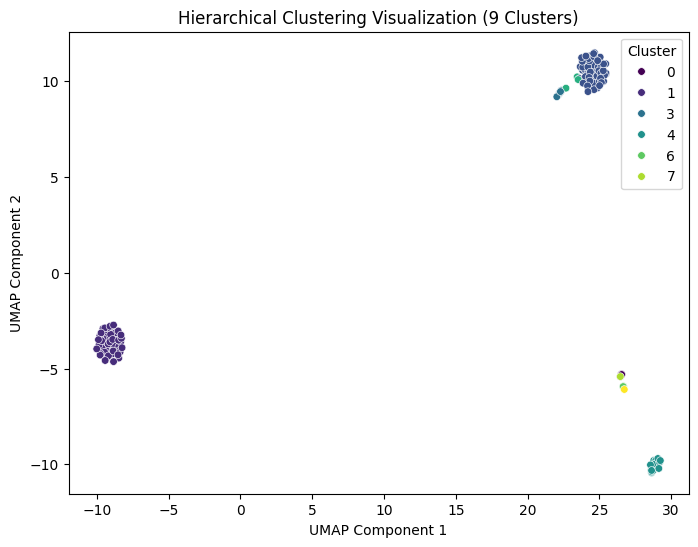

In [8]:
labels, silhouette_avg, dbi_score = apply_hierarchical_clustering(tag_embeddings, 
                                                                  n_clusters=BEST_OPTIMIZE_HIERARCHICAL["n_clusters"], 
                                                                  metric="cosine", 
                                                                  linkage=BEST_OPTIMIZE_HIERARCHICAL["linkage"], 
                                                                  visualize=True)

In [9]:
sentences = pd.read_parquet("input/tag_sentences.parquet").squeeze()
sentences

0               [history, museum, specialty, museum]
1                                        [bar, club]
2                                [sacred, religious]
3                                       [boat, tour]
4                                      [body, water]
                            ...                     
1761                                         [beach]
1762                                        [bridge]
1763    [sacred, religious, architectural, building]
1764                                         [beach]
1765                                       [lookout]
Name: cleaned_tags, Length: 1766, dtype: object

In [10]:
labels

array([0, 2, 2, 4, 2, 4, 0, 4, 4, 2, 6, 4, 2, 1, 2, 1, 1, 1, 1, 1, 1, 2,
       2, 1, 2, 1, 1, 1, 1, 1, 2, 2, 2, 1, 2, 0, 2, 4, 2, 1, 1, 4, 1, 1,
       2, 6, 1, 2, 1, 1, 2, 2, 3, 1, 5, 2, 2, 2, 1, 2, 2, 0, 4, 2, 1, 1,
       1, 1, 1, 1, 2, 1, 2, 1, 4, 3, 2, 1, 1, 1, 2, 2, 2, 1, 3, 1, 0, 1,
       3, 2, 2, 3, 2, 2, 4, 2, 2, 1, 2, 4, 2, 1, 4, 2, 2, 2, 2, 2, 1, 1,
       4, 3, 1, 2, 2, 2, 1, 2, 5, 1, 1, 4, 2, 4, 1, 1, 1, 1, 1, 2, 1, 2,
       1, 1, 1, 1, 2, 2, 1, 1, 1, 2, 4, 2, 2, 1, 1, 1, 2, 2, 7, 2, 2, 2,
       3, 2, 2, 4, 1, 1, 2, 3, 4, 1, 2, 8, 5, 4, 2, 2, 4, 1, 1, 2, 2, 3])

In [11]:
clusters = {}
for i, label in enumerate(labels):
    if label != -1:  # Ignore noise points
        clusters.setdefault(label, []).append(list(sentences.iloc[i]))  # Convert NumPy array to Python list


In [12]:
clusters

{0: [['history', 'museum', 'specialty', 'museum'],
  ['garden'],
  [],
  ['beach'],
  ['beach']],
 2: [['bar', 'club'],
  ['sacred', 'religious'],
  ['body', 'water'],
  ['hot', 'spring', 'geyser'],
  ['shopping', 'mall'],
  ['historic'],
  ['sacred', 'religious'],
  ['monument', 'statue'],
  ['specialty', 'museum'],
  ['sacred', 'religious'],
  ['sacred', 'religious'],
  ['nature', 'wildlife', 'area'],
  ['zoo'],
  ['waterfall'],
  ['natural', 'history', 'museum'],
  ['cavern', 'cave', 'nature', 'wildlife', 'area'],
  [],
  ['scuba', 'snorkeling', 'adrenaline', 'extreme', 'tour'],
  [],
  ['shopping', 'mall'],
  ['national', 'park'],
  [],
  ['theme', 'park', 'water', 'park'],
  [],
  ['waterfall'],
  ['flea', 'street', 'market'],
  ['neighborhood'],
  ['history', 'museum', 'specialty', 'museum'],
  ['art', 'gallery'],
  ['cavern', 'cave', 'geologic', 'formation'],
  ['beach'],
  [],
  ['geologic', 'formation'],
  ['sightseeing', 'tour'],
  ['observation', 'deck', 'tower', 'lookout'],

In [92]:
tag_embeddings[['cluster', 'cleaned_tags']]

,cluster,cleaned_tags
0,0,history museum specialty museum
1,21,bar club
2,15,sacred religious
3,10,boat tour
4,28,body water
...,...,...
1761,7,beach
1762,20,bridge
1763,2,sacred religious architectural building
1764,7,beach


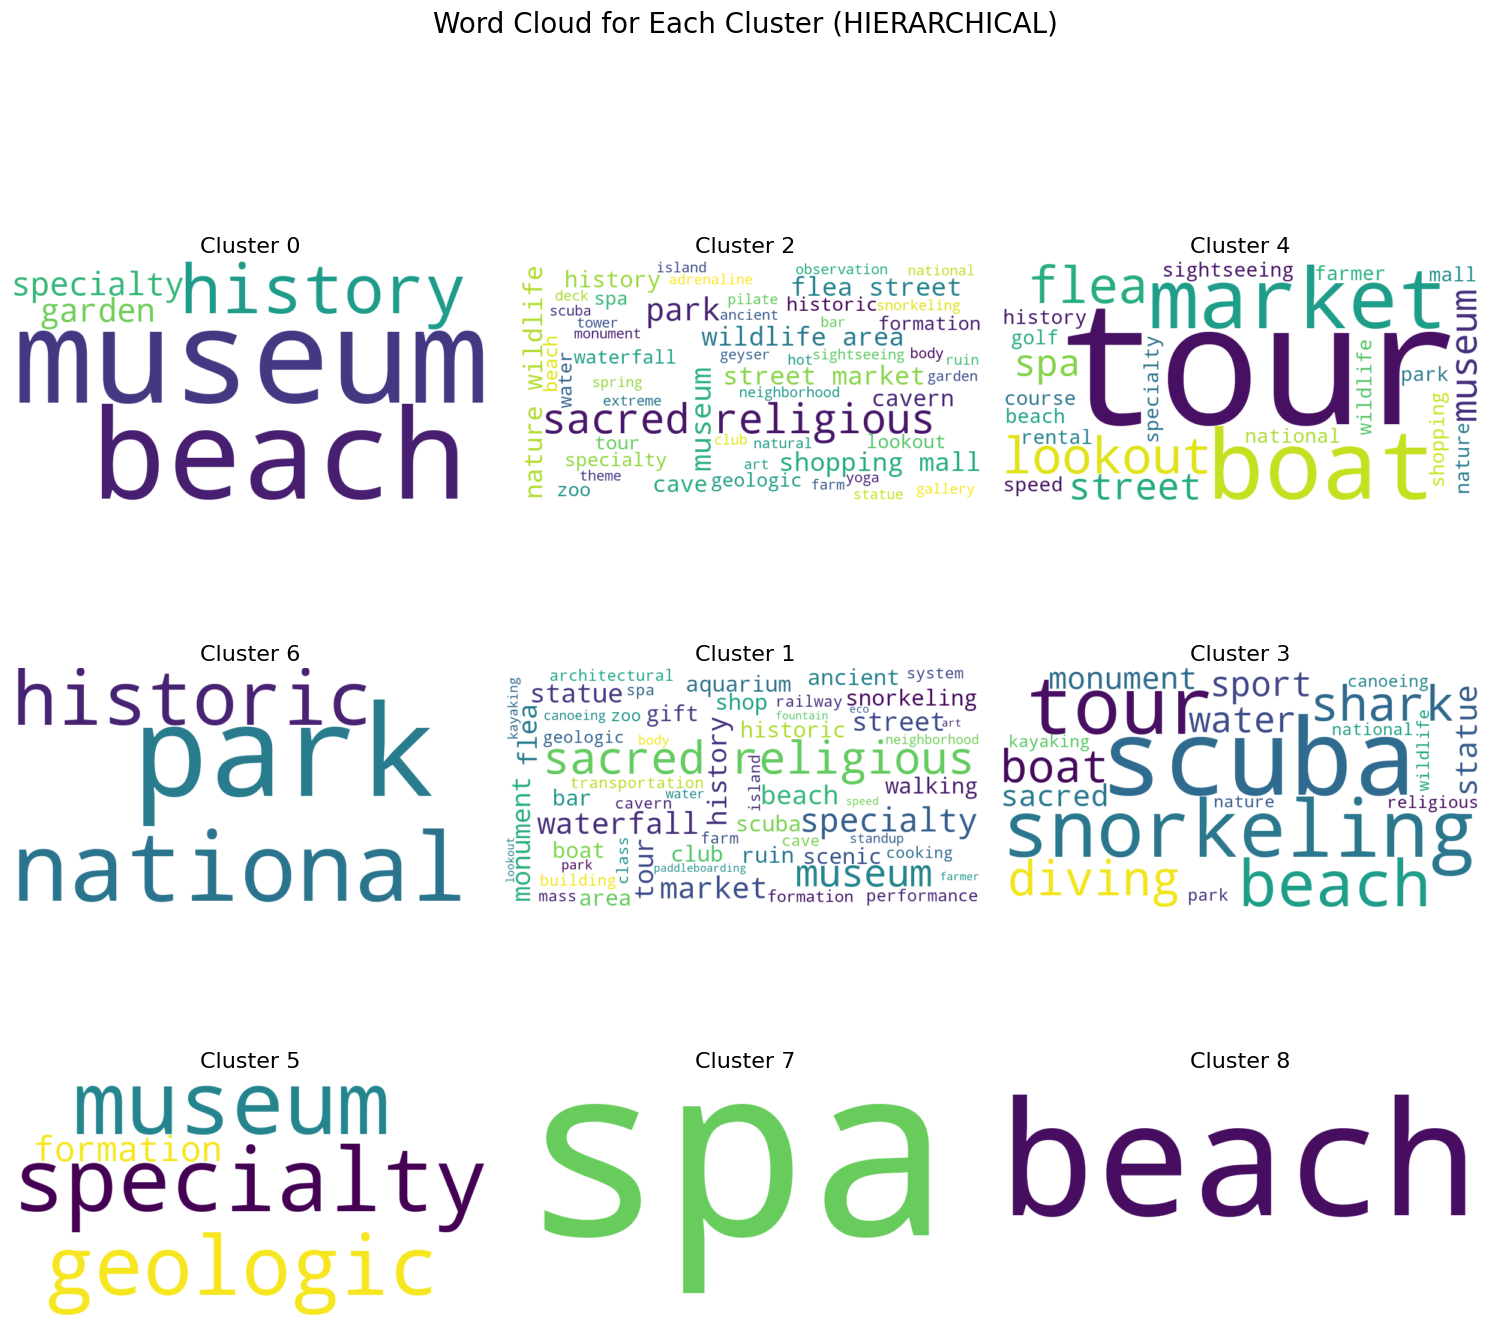

In [13]:
def flatten_list(nested_list):
    return [item for sublist in nested_list for item in (sublist if isinstance(sublist, list) else [sublist])]

data_clusters = {cluster_id: flatten_list(words) for cluster_id, words in clusters.items()}

# Plot Word Clouds
num_clusters = len(data_clusters)
columns = 3
rows = (num_clusters + columns - 1) // columns

fig, axes = plt.subplots(rows, columns, figsize=(15, 5 * rows))
fig.suptitle("Word Cloud for Each Cluster (HIERARCHICAL)", fontsize=20)

axes = axes.flatten()

for idx, (cluster_id, words) in enumerate(data_clusters.items()):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(words))
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f"Cluster {cluster_id}", fontsize=16)
    axes[idx].axis('off')

# Hide any unused subplots
for i in range(len(data_clusters), len(axes)):
    axes[i].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [14]:
type(data_clusters)

dict

In [17]:
data_clusters

{0: ['history', 'museum', 'specialty', 'museum', 'garden', 'beach', 'beach'],
 2: ['bar',
  'club',
  'sacred',
  'religious',
  'body',
  'water',
  'hot',
  'spring',
  'geyser',
  'shopping',
  'mall',
  'historic',
  'sacred',
  'religious',
  'monument',
  'statue',
  'specialty',
  'museum',
  'sacred',
  'religious',
  'sacred',
  'religious',
  'nature',
  'wildlife',
  'area',
  'zoo',
  'waterfall',
  'natural',
  'history',
  'museum',
  'cavern',
  'cave',
  'nature',
  'wildlife',
  'area',
  'scuba',
  'snorkeling',
  'adrenaline',
  'extreme',
  'tour',
  'shopping',
  'mall',
  'national',
  'park',
  'theme',
  'park',
  'water',
  'park',
  'waterfall',
  'flea',
  'street',
  'market',
  'neighborhood',
  'history',
  'museum',
  'specialty',
  'museum',
  'art',
  'gallery',
  'cavern',
  'cave',
  'geologic',
  'formation',
  'beach',
  'geologic',
  'formation',
  'sightseeing',
  'tour',
  'observation',
  'deck',
  'tower',
  'lookout',
  'lookout',
  'cavern',


In [19]:
df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_clusters.items()]))

# Save to Parquet
df.to_parquet("output/hierarchical_clusters.parquet", index=False)